Compare classic evaluation metrics (like Accuracy and Macro F1) along with probability calibration metrics (Log Loss and Brier Score) across SVM, Random Forest, and XGBoost.

In [5]:
%uv pip install xgboost

Using Python 3.12.6 environment at: /usr/local
Resolved 4 packages in 89ms
⠙ Preparing packages... (0/1)
⠙ Preparing packages... (0/1)
⠙ Preparing packages... (0/1)
⠙ Preparing packages... (0/1)
⠙ Preparing packages... (0/1)
⠙ Preparing packages... (0/1)
⠙ Preparing packages... (0/1)
⠙ Preparing packages... (0/1)
⠙ Preparing packages... (0/1)
⠙ Preparing packages... (0/1)
⠙ Preparing packages... (0/1)
⠙ Preparing packages... (0/1)
⠙ Preparing packages... (0/1)
⠙ Preparing packages... (0/1)
⠙ Preparing packages... (0/1)
⠙ Preparing packages... (0/1)
⠙ Preparing packages... (0/1)
⠙ Preparing packages... (0/1)
⠙ Preparing packages... (0/1)
⠙ Preparing packages... (0/1)
⠹ Preparing packages... (0/1)
⠹ Preparing packages... (0/1)
⠹ Preparing packages... (0/1)
⠹ Preparing packages... (0/1)
⠸ Preparing packages... (0/1)
⠸ Preparing packages... (0/1)
⠸ Preparing packages... (0/1)
⠸ Preparing packages... (0/1)
⠸ Preparing packages... (0/1)
⠼ Preparing packages... (0/1)
⠼ Preparing packages... (

In [6]:
import io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.metrics import accuracy_score, f1_score, log_loss, brier_score_loss

from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.calibration import calibration_curve, CalibratedClassifierCV
from sklearn.preprocessing import label_binarize
from sklearn.datasets import make_classification


In [7]:
train_csv = """Date,Location,Temp_Max_C,Temp_Min_C,Humidity_Pct,Wind_Speed_Kmh,Precipitation_mm,Weather_Type
2026-07-01,Singapore,31.5,25.0,82,16.5,4.2,Rainy
2026-07-02,Singapore,32.0,26.1,78,12.0,0.0,Sunny
2026-07-03,Singapore,30.8,24.5,85,25.4,18.0,Rainy
2026-07-04,Singapore,32.2,25.8,75,9.5,0.0,Sunny
2026-07-05,Singapore,31.0,25.2,80,14.2,2.1,Cloudy
2026-07-06,Singapore,31.8,26.0,77,11.0,0.0,Sunny
2026-07-07,Singapore,29.5,23.8,92,28.1,34.5,Rainy
2026-07-08,Singapore,31.2,25.5,81,13.0,0.5,Cloudy
2026-07-09,Singapore,32.5,26.3,74,10.2,0.0,Sunny
2026-07-10,Singapore,30.5,24.8,86,19.0,8.4,Rainy
2026-07-11,Singapore,32.1,25.9,76,11.5,0.0,Sunny
2026-07-12,Singapore,31.4,25.1,83,15.0,3.8,Rainy
2026-07-13,Singapore,31.0,25.3,82,12.8,1.2,Cloudy
2026-07-14,Singapore,32.4,26.2,73,8.7,0.0,Sunny
2026-07-15,Singapore,29.8,24.0,89,22.0,14.6,Rainy
2026-07-16,Singapore,31.6,25.6,79,13.4,0.0,Sunny
2026-07-17,Singapore,30.9,24.9,84,17.2,5.0,Rainy
2026-07-18,Singapore,32.0,25.8,77,10.6,0.0,Sunny
2026-07-19,Singapore,31.3,25.4,81,14.0,0.8,Cloudy
2026-07-20,Singapore,30.2,24.3,88,26.5,22.1,Rainy
2026-07-21,Singapore,32.6,26.5,72,9.0,0.0,Sunny
2026-07-22,Singapore,31.7,25.7,80,11.8,1.5,Cloudy
2026-07-23,Singapore,30.0,24.2,90,23.4,19.8,Rainy
2026-07-24,Singapore,32.3,26.0,76,10.5,0.0,Sunny"""

test_csv = """Date,Location,Temp_Max_C,Temp_Min_C,Humidity_Pct,Wind_Speed_Kmh,Precipitation_mm,Weather_Type
2026-07-25,Singapore,31.1,25.2,83,13.2,2.7,Cloudy
2026-07-26,Singapore,32.8,26.6,71,8.1,0.0,Sunny
2026-07-27,Singapore,29.2,23.5,94,30.2,42.0,Rainy
2026-07-28,Singapore,31.5,25.4,79,12.6,0.0,Sunny
2026-07-29,Singapore,30.6,24.7,85,18.5,7.1,Rainy
2026-07-30,Singapore,31.9,25.9,78,11.1,0.0,Sunny"""

train_df = pd.read_csv(io.StringIO(train_csv))
test_df = pd.read_csv(io.StringIO(test_csv))

In [8]:
features = ['Temp_Max_C', 'Temp_Min_C', 'Humidity_Pct', 'Wind_Speed_Kmh', 'Precipitation_mm']
X_train, X_test = train_df[features], test_df[features]

le = LabelEncoder()
y_train = le.fit_transform(train_df['Weather_Type'])
y_test = le.transform(test_df['Weather_Type'])
classes = np.unique(y_train)

# --- MULTI-CLASS BRIER SCORE FUNCTION ---
def multiclass_brier_score(y_true, y_prob_matrix, classes):
    # One-hot encode the true labels to compute distances per class channel
    y_true_onehot = label_binarize(y_true, classes=classes)
    brier_scores = []
    for idx in range(len(classes)):
        score = brier_score_loss(y_true_onehot[:, idx], y_prob_matrix[:, idx])
        brier_scores.append(score)
    return np.mean(brier_scores)

# --- DICTIONARY OF BASE ENGINES ---
models = {
    'SVM': SVC(probability=True, random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='mlogloss')
}

In [9]:
results = []

# --- EXECUTE & EVALUATE ---
for name, model in models.items():
    # A. Uncalibrated Model Evaluation
    model.fit(X_train, y_train)
    uncal_preds = model.predict(X_test)
    uncal_probs = model.predict_proba(X_test)
    
    # B. Calibrated Model Evaluation (Sigmoid Cross-Validation Layer)
    cal_model = CalibratedClassifierCV(estimator=model, method='sigmoid', cv=3)
    cal_model.fit(X_train, y_train)
    cal_preds = cal_model.predict(X_test)
    cal_probs = cal_model.predict_proba(X_test)
    
    # Store metrics for both setups
    results.append({
        'Model': name,
        'Type': 'Standard',
        'Accuracy': accuracy_score(y_test, uncal_preds),
        'Macro F1': f1_score(y_test, uncal_preds, average='macro'),
        'Log Loss (⬇️)': log_loss(y_test, uncal_probs, labels=classes),
        'Brier Score (⬇️)': multiclass_brier_score(y_test, uncal_probs, classes)
    })
    
    results.append({
        'Model': name,
        'Type': 'Calibrated',
        'Accuracy': accuracy_score(y_test, cal_preds),
        'Macro F1': f1_score(y_test, cal_preds, average='macro'),
        'Log Loss (⬇️)': log_loss(y_test, cal_probs, labels=classes),
        'Brier Score (⬇️)': multiclass_brier_score(y_test, cal_probs, classes)
    })

# --- RESULTS TABLE ---
df_results = pd.DataFrame(results)
# Sort to compare Standard vs Calibrated pairs directly
df_results = df_results.sort_values(by=['Model', 'Type'], ascending=[True, False]).reset_index(drop=True)

print("\n========================= PERFORMANCE METRICS COMPARISON =========================")
print(df_results.to_string(index=False, formatters={
    'Accuracy': '{:,.2%}'.format,
    'Macro F1': '{:,.2%}'.format,
    'Log Loss (⬇️)': '{:,.4f}'.format,
    'Brier Score (⬇️)': '{:,.4f}'.format
}))
print("==================================================================================\n")


========================= PERFORMANCE METRICS COMPARISON =========================
        Model       Type Accuracy Macro F1 Log Loss (⬇️) Brier Score (⬇️)
Random Forest   Standard  100.00%  100.00%        0.1144           0.0197
Random Forest Calibrated  100.00%  100.00%        0.3986           0.0596
          SVM   Standard   83.33%   61.90%        0.5224           0.0920
          SVM Calibrated   83.33%   61.90%        0.7574           0.1426
      XGBoost   Standard  100.00%  100.00%        0.0642           0.0021
      XGBoost Calibrated  100.00%  100.00%        0.4934           0.0790



### Reliability Diagram

Because the classic Calibration Curve (Reliability Diagram) is mathematically designed to work only on binary decisions (True vs. False, or 1 vs. 0).

It plots the "Fraction of Positives" on the y-axis, which answers a single binary question: “Out of the times the model said 70% confidence, how many times was it actually a Yes?”

In a multi-class problem with 3 options like Singapore's weather (Sunny, Rainy, Cloudy), it cannot be easily squeezed them all onto a single 2D line graph.

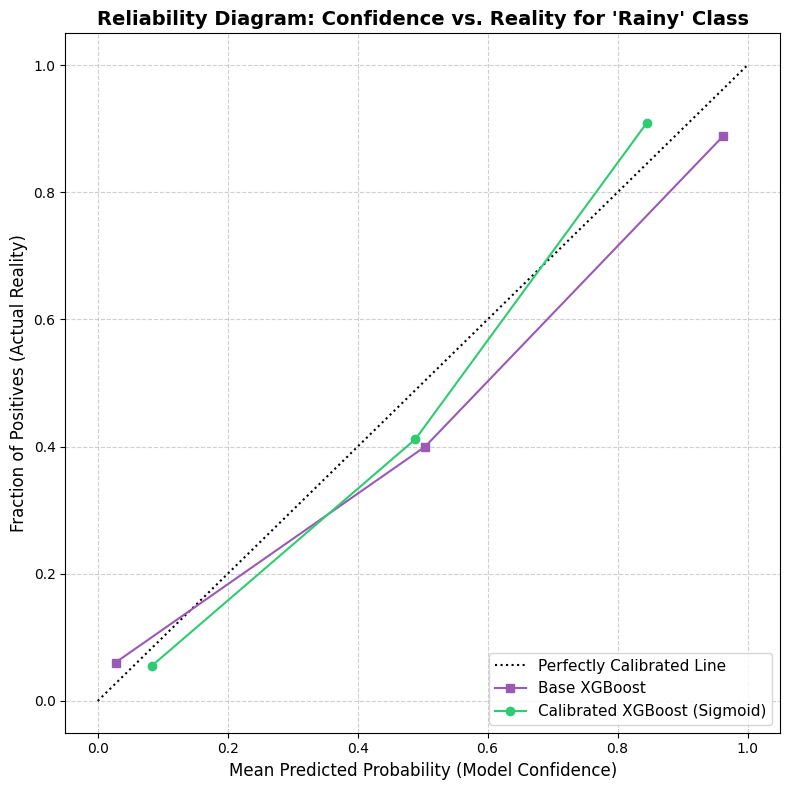

In [14]:
 Base Uncalibrated XGBoost
base_model = XGBClassifier(random_state=42, eval_metric='mlogloss')
base_model.fit(X_train, y_train)
base_probs = base_model.predict_proba(X_test)

# Calibrated XGBoost
cal_wrapper = CalibratedClassifierCV(estimator=XGBClassifier(random_state=42, eval_metric='mlogloss'), method='sigmoid', cv=5)
cal_wrapper.fit(X_train, y_train)
cal_probs = cal_wrapper.predict_proba(X_test)


# --- 3. GENERATE THE CALIBRATION CURVE CHART ---

# Since the dataset has 3 classes, calibration curves require a binary target.
# check how well the models calibrate for predicting "Rainy" (Class 1) vs Not Rainy.
y_test_binary = label_binarize(y_test, classes=classes)[:, 1]

# Extract the probabilities specifically for the "Rainy" class
xgb_uncal_rainy_probs = base_probs[:, 1]  
xgb_cal_rainy_probs = cal_probs[:, 1]      

plt.figure(figsize=(8, 8))

# 1. Plot the Perfect Calibration Baseline (The 45-degree line)
plt.plot([0, 1], [0, 1], "k:", label="Perfectly Calibrated Line")

# 2. Compute and Plot Uncalibrated XGBoost
prob_true_uncal, prob_pred_uncal = calibration_curve(y_test_binary, xgb_uncal_rainy_probs, n_bins=3)
plt.plot(prob_pred_uncal, prob_true_uncal, "s-", color='#9b59b6', label="Base XGBoost")

# 3. Compute and Plot Calibrated XGBoost
prob_true_cal, prob_pred_cal = calibration_curve(y_test_binary, xgb_cal_rainy_probs, n_bins=3)
plt.plot(prob_pred_cal, prob_true_cal, "o-", color='#2ecc71', label="Calibrated XGBoost (Sigmoid)")

# Chart Customization
plt.xlabel("Mean Predicted Probability (Model Confidence)", fontsize=12)
plt.ylabel("Fraction of Positives (Actual Reality)", fontsize=12)
plt.title("Reliability Diagram: Confidence vs. Reality for 'Rainy' Class", fontsize=14, fontweight='bold')
plt.xlim([-0.05, 1.05])
plt.ylim([-0.05, 1.05])
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc="lower right", fontsize=11)

plt.tight_layout()
plt.show()

### Multi-class Data Simulation

In [11]:
# 1. SETUP MULTI-CLASS SIMULATED DATA 
X, y = make_classification(n_samples=800, n_features=10, n_classes=3, n_informative=6, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

classes = np.unique(y)
class_names = ['Cloudy', 'Rainy', 'Sunny']
colors = ['#7f8c8d', '#2ecc71', '#f1c40f'] # Grey, Green, Yellow

# Binarize labels for multi-class reliability mapping
y_test_onehot = label_binarize(y_test, classes=classes)

In [12]:
# 2. INITIALIZE ALL THREE CALIBRATED MODELS
models = {
    'SVM': CalibratedClassifierCV(estimator=SVC(probability=True, random_state=42), method='sigmoid', cv=5),
    'Random Forest': CalibratedClassifierCV(estimator=RandomForestClassifier(random_state=42), method='sigmoid', cv=5),
    'XGBoost': CalibratedClassifierCV(estimator=XGBClassifier(random_state=42, eval_metric='mlogloss'), method='sigmoid', cv=5)
}

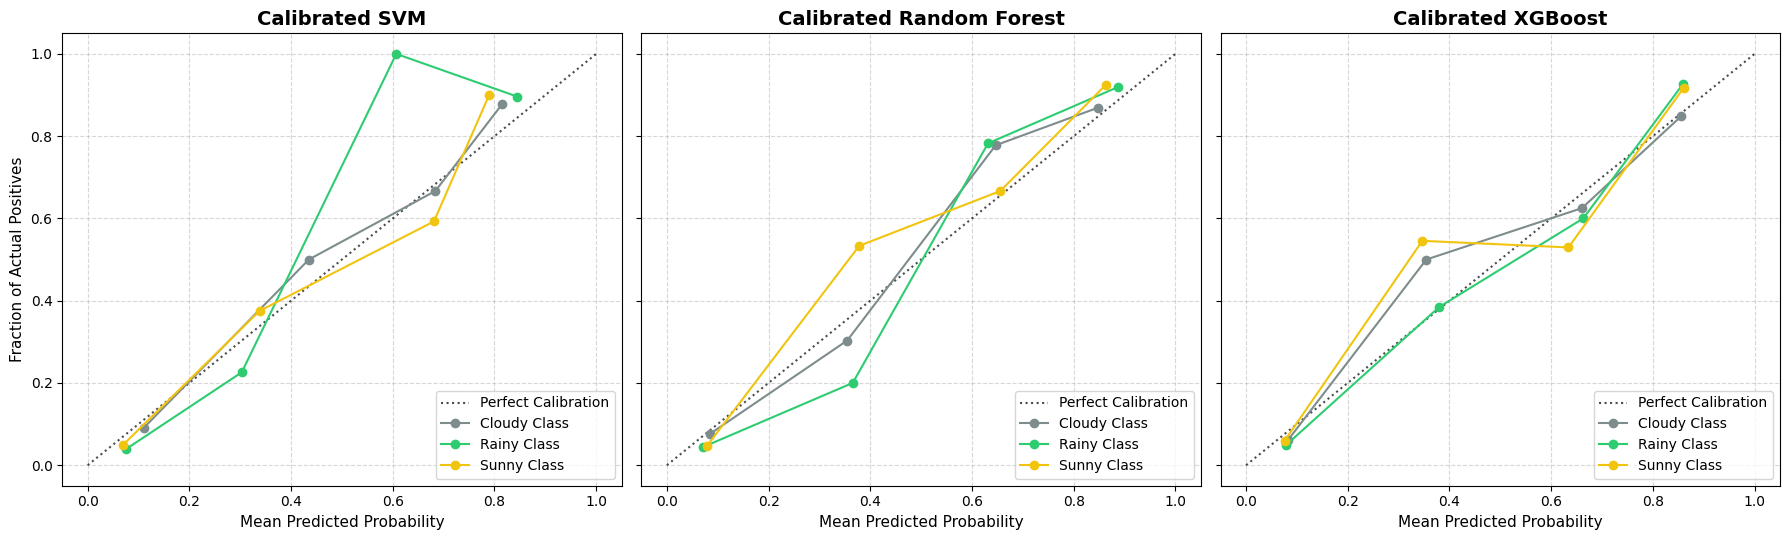

In [13]:
# 3. GENERATE THE 3-CHART GRID (1 Row, 3 Columns)
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5), sharey=True)

for ax_idx, (model_name, model) in enumerate(models.items()):
    ax = axes[ax_idx]
    
    # Train the calibrated wrapper
    model.fit(X_train, y_train)
    cal_probs = model.predict_proba(X_test)
    
    # Plot the ideal 45-degree calibration anchor line
    ax.plot([0, 1], [0, 1], "k:", alpha=0.7, label="Perfect Calibration")
    
    # Extract and plot calibration curve for each of the 3 classes
    for i, class_label in enumerate(class_names):
        prob_true, prob_pred = calibration_curve(y_test_onehot[:, i], cal_probs[:, i], n_bins=4)
        ax.plot(prob_pred, prob_true, "o-", color=colors[i], label=f"{class_label} Class")
        
    # Formatting the subplot panels
    ax.set_title(f"Calibrated {model_name}", fontsize=14, fontweight='bold')
    ax.set_xlabel("Mean Predicted Probability", fontsize=11)
    if ax_idx == 0:
        ax.set_ylabel("Fraction of Actual Positives", fontsize=11)
    
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend(loc="lower right", fontsize=10)
    ax.set_xlim([-0.05, 1.05])
    ax.set_ylim([-0.05, 1.05])

plt.tight_layout()
plt.show()